# Homework 3: Download and analyze any data using tools you learned in class

### IMPORTANT: Save your notebook and files (if you import locally) 
### IMPORTANT: See my example data folder: data/hw/hw_3/cory-baird
### **HW Requirements**

- **Relative Paths Only**
  - Use relative paths from the project root (e.g., `data/hw/hw_3/student-name/data.csv`).
  - Never hardcode absolute paths specific to your local machine (e.g., `/Users/username/...`).
- **File Size Limit**
  - Any committed dataset must be reasonable in size (strictly under 10 megabytes).
    - If you have to filter the dataset (to make it smaller) and upload a smaller version

- **Dataset Selection**
  - Select a policy-relevant dataset with at least 50 observations (e.g., 50 states, countries, or time periods) for meaningful analysis.
  - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Data Acquisition**
  - You are highly encouraged to fetch data programmatically using an API (e.g. using `requests` with World Bank, US Census, or other public APIs) or load a direct public URL.

  - Alternatively, you may upload a local file, provided it is committed to your repository.
    - If you read csv/parquet etc use relative paths such as `data/hw/hw_3/student-name/data.csv`.
    - You can use example datasets from [here](../../../docs/example_datasets.md)

- **Reproducibility**
  - Commit both this notebook and the dataset so that your grader can run all cells from top to bottom out-of-the-box.

## IMPORTANT

---
### **Objectives**
- Select, acquire, and load a policy-relevant dataset of your choice.
- Apply clean code principles (environment checks, Python collections, standardized variable naming).
- Preprocess and standardize columns using Pandas techniques.
- Programmatically merge your primary dataset with a secondary source.
- Segment your data and run custom aggregations (using groupby or custom grouping strategies).
- Create customized visualizations and run exploratory regression analysis to discover policy insights.

### **Concept Reference Map**
- **Data Acquisition**: APIs (`requests` library), reading Parquet/CSV (Week 2/3 basics, Week 4 `1-visualization_basics.ipynb`)
- **Data Manipulation**: Selecting, renaming columns, filtering (`query()`), dropping NaNs (Week 4 `1-visualization_basics.ipynb`)
- **Aggregation**: Groupby, descriptive statistics (`describe()`, `mean()`) (Week 4 `1-visualization_basics.ipynb`)
- **Data Merging**: Pandas `merge()` matching indices or keys (Week 4 `2-merging_practice.ipynb`)
- **Visualization**: Scatter plots, line/bar charts, customization (Week 4 / Week 6 `1-regression.ipynb`)
- **Modeling**: Simple Linear Regression (`statsmodels`), line of best fit (Week 6 `1-regression.ipynb`)

---

### **Part 1: Data Acquisition & Environment Preparation**

- **Environment Setup**
  - Use python's `os` library (as reviewed in Week 3) to print your current working directory (`os.getcwd()`) and list the files in your project directory (`os.listdir()`) to ensure your paths are configured correctly.
- **Acquisition Steps**
  - Programmatically fetch data using `requests` or read directly from a public URL using Pandas.
  - If loading a committed local dataset, load it using a relative path.
- **Code Requirements**
  - Define variables using standardized, descriptive names.
  - Keep all function and method arguments on a single line.
  - Do not use docstrings (`""" """`) or runtime type checking in your helper methods.

In [ ]:
import os
import pandas as pd
import requests
import matplotlib.pyplot as plt

# You can use example datasets here docs/example_datasets.md

# 1. Print environment details (working directory and local folder contents)
# If you read csv/parquet etc use relative paths such as data/hw/hw_3/student-name/data.csv
print(f"current working directory:{os.getcwd()}")
print("\nFiles in current directory:")
print(os.listdir("."))

# 2. Acquire and load your primary dataset
# YOUR CODE HERE
import requests
import pandas as pd
import io

def download_worldbank():
    url = "https://datacatalogapi.worldbank.org/dexapps/fone/api/view?viewId=DS01079&top=200&type=csv"
    response = requests.get(url)
    response.raise_for_status()
    df = pd.read_csv(io.BytesIO(response.content))
    return df

df = download_worldbank()



current working directory:e:\东京大学\datascience-publicpolicy-2026\notebooks\hw\hw_3

Files in current directory:
['HW 3_HUANG Shuo.ipynb']


### **Dataset Context & Relevance**

- **Dataset Source**
  - Specify the source of your dataset (e.g., API name, public organization, or website URL).

- *Write your source here*
 IFC Investment Projects in Kenya https://financesone.worldbank.org/ifc-investment-projects-in-kenya/DS01079

### **Part 2: Data Cleaning & Preprocessing**

- **Data Inspection**
  - Inspect column names, data types, and non-null counts using `.info()` and `.head()`.
- **Preprocessing Tasks**
  - Select a subset of columns necessary for your policy inquiry.
  - Standardize column names to a clean formatting (preferably `snake_case` or another consistent style).
  - Identify and handle missing values (`NaN`s) by dropping or filling them.
- **Python Grammar Tip**
  - You are encouraged to use a Python dictionary (as reviewed in Week 2 & 3) to map and rename your column names cleanly.

In [111]:
# 1. Inspect data structure using pandas methods
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 20 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   date_disclosed                                         119 non-null    object 
 1   project_name                                           119 non-null    object 
 2   document_type                                          119 non-null    object 
 3   project_number                                         119 non-null    int64  
 4   product_line                                           113 non-null    object 
 5   company_name                                           117 non-null    object 
 6   country                                                119 non-null    object 
 7   ifc_country_code                                       119 non-null    object 
 8   industry                                          

,date_disclosed,project_name,document_type,project_number,product_line,company_name,country,ifc_country_code,industry,environmental_category,department,status,projected_board_date,ifc_investment_for_risk_managementmillion__usd,ifc_investment_for_guaranteemillion__usd,ifc_investment_for_loanmillion__usd,ifc_investment_for_equitymillion__usd,total_ifc_investment_as_approved_by_boardmillion__usd,wb_country_code,as_of_date
0,05/15/1995 00:00:00,MAGADI SODA COMPANY LTD.,Summary of Proposed Investment (Disclosure Pol...,4853,Loan,TATA CHEMICALS MAGADI LTD,Kenya,KEN,Manufacturing,B - Limited,"Gbl Ind, Manufact, Agribus &amp; Services",Completed,NaN,NaN,NaN,9.00,NaN,9.00,KE,06/01/2026 00:00:00
1,06/05/1995 00:00:00,AEF Bawan Roses (formerly Island Farm),Summary of Proposed Investment (Disclosure Pol...,5142,Loan,Bawan Roses Limited,Kenya,KEN,Agribusiness and Forestry,B - Limited,Regional Industry - MAS Africa,Completed,NaN,NaN,NaN,0.50,NaN,0.50,KE,06/01/2026 00:00:00
2,09/07/1995 00:00:00,AEF K-Rep Bank Limited,Summary of Proposed Investment (Disclosure Pol...,7017,Equity,K-REP BANK LIMITED,Kenya,KEN,Financial Markets,C - No Impact,"Global Industry, Financial Markets",Completed,NaN,NaN,NaN,NaN,1.00,1.00,KE,06/01/2026 00:00:00
3,12/15/1995 00:00:00,Panafrican Paper Mills Ltd.,Summary of Proposed Investment (Disclosure Pol...,7206,Loan,Panafrican Airways Limited,Kenya,KEN,Agribusiness and Forestry,B - Limited,"Gbl Ind, Manufact, Agribus &amp; Services",Completed,NaN,NaN,NaN,15.00,NaN,15.00,KE,06/01/2026 00:00:00
4,04/23/1996 00:00:00,AEF Equitea EPZ Company Limited,Summary of Proposed Investment (Disclosure Pol...,7366,Loan,Equitea EPZ Company Ltd.,Kenya,KEN,Agribusiness and Forestry,B - Limited,Regional Industry - MAS Africa,Completed,NaN,NaN,NaN,0.31,0.12,0.43,KE,06/01/2026 00:00:00


In [112]:
# 2. Rename columns and select a clean subset
df=df.rename({"environmental_category": "environmental_impact_level", "date_disclosed": "year"}, axis=1)
df["year"] = pd.to_datetime(df["year"]).dt.year
df.head()

,year,project_name,document_type,project_number,product_line,company_name,country,ifc_country_code,industry,environmental_impact_level,department,status,projected_board_date,ifc_investment_for_risk_managementmillion__usd,ifc_investment_for_guaranteemillion__usd,ifc_investment_for_loanmillion__usd,ifc_investment_for_equitymillion__usd,total_ifc_investment_as_approved_by_boardmillion__usd,wb_country_code,as_of_date
0,1995,MAGADI SODA COMPANY LTD.,Summary of Proposed Investment (Disclosure Pol...,4853,Loan,TATA CHEMICALS MAGADI LTD,Kenya,KEN,Manufacturing,B - Limited,"Gbl Ind, Manufact, Agribus &amp; Services",Completed,NaN,NaN,NaN,9.00,NaN,9.00,KE,06/01/2026 00:00:00
1,1995,AEF Bawan Roses (formerly Island Farm),Summary of Proposed Investment (Disclosure Pol...,5142,Loan,Bawan Roses Limited,Kenya,KEN,Agribusiness and Forestry,B - Limited,Regional Industry - MAS Africa,Completed,NaN,NaN,NaN,0.50,NaN,0.50,KE,06/01/2026 00:00:00
2,1995,AEF K-Rep Bank Limited,Summary of Proposed Investment (Disclosure Pol...,7017,Equity,K-REP BANK LIMITED,Kenya,KEN,Financial Markets,C - No Impact,"Global Industry, Financial Markets",Completed,NaN,NaN,NaN,NaN,1.00,1.00,KE,06/01/2026 00:00:00
3,1995,Panafrican Paper Mills Ltd.,Summary of Proposed Investment (Disclosure Pol...,7206,Loan,Panafrican Airways Limited,Kenya,KEN,Agribusiness and Forestry,B - Limited,"Gbl Ind, Manufact, Agribus &amp; Services",Completed,NaN,NaN,NaN,15.00,NaN,15.00,KE,06/01/2026 00:00:00
4,1996,AEF Equitea EPZ Company Limited,Summary of Proposed Investment (Disclosure Pol...,7366,Loan,Equitea EPZ Company Ltd.,Kenya,KEN,Agribusiness and Forestry,B - Limited,Regional Industry - MAS Africa,Completed,NaN,NaN,NaN,0.31,0.12,0.43,KE,06/01/2026 00:00:00


In [113]:
# 3. Filter row or column filters if necessary
df=df[['project_name','year', 'document_type', 'product_line', 'country', 'industry', 'environmental_impact_level']]
df.head()

,project_name,year,document_type,product_line,country,industry,environmental_impact_level
0,MAGADI SODA COMPANY LTD.,1995,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Manufacturing,B - Limited
1,AEF Bawan Roses (formerly Island Farm),1995,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Agribusiness and Forestry,B - Limited
2,AEF K-Rep Bank Limited,1995,Summary of Proposed Investment (Disclosure Pol...,Equity,Kenya,Financial Markets,C - No Impact
3,Panafrican Paper Mills Ltd.,1995,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Agribusiness and Forestry,B - Limited
4,AEF Equitea EPZ Company Limited,1996,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Agribusiness and Forestry,B - Limited


In [114]:
# 4. Handle missing values (NaNs) if necessary
df = df.dropna(subset=["year", "document_type", "product_line", "country", "industry", "environmental_impact_level"])
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 113 entries, 0 to 115
Data columns (total 7 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   project_name                113 non-null    object
 1   year                        113 non-null    int32 
 2   document_type               113 non-null    object
 3   product_line                113 non-null    object
 4   country                     113 non-null    object
 5   industry                    113 non-null    object
 6   environmental_impact_level  113 non-null    object
dtypes: int32(1), object(6)
memory usage: 6.6+ KB


### **Part 3: Merging Datasets**

- **Secondary Source Selection**
  - Programmatically download/read another related dataset.
- **Clean & Standardize**
  - Preprocess and rename the columns of the secondary dataset.
- **Merging Process**
  - Merge both datasets on a common key (such as country code or year).
  - Display the shape and head of your merged dataset to verify that the join was successful.

In [115]:
# 1. Load and clean the secondary dataset
def download_kenya_gdp(date_start, date_end):
    url_base = "https://api.worldbank.org/v2/"
    country_code = "KEN"
    indicator = "NY.GDP.MKTP.CD"
    url = f"{url_base}country/{country_code}/indicator/{indicator}?date={date_start}:{date_end}&per_page=30000"
    response = requests.get(url)
    df = pd.read_xml(io.BytesIO(response.content))
    return df

df_gdp = download_kenya_gdp(1995, 2026)
df_gdp = df_gdp.dropna(subset=["value"])
df_gdp = df_gdp.rename({"date": "year", "value": "gdp"}, axis=1)
df_gdp=df_gdp[['gdp','year', 'indicator']]
df_gdp.head()

,gdp,year,indicator
1,1.203396e+11,2024,GDP (current US$)
2,1.075009e+11,2023,GDP (current US$)
3,1.144490e+11,2022,GDP (current US$)
4,1.097037e+11,2021,GDP (current US$)
5,1.006575e+11,2020,GDP (current US$)


In [116]:
# 2. Merge your datasets on a common key
merged_df = pd.merge(df, df_gdp, on="year")
merged_df.info()
merged_df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 108 entries, 0 to 107
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   project_name                108 non-null    object 
 1   year                        108 non-null    int32  
 2   document_type               108 non-null    object 
 3   product_line                108 non-null    object 
 4   country                     108 non-null    object 
 5   industry                    108 non-null    object 
 6   environmental_impact_level  108 non-null    object 
 7   gdp                         108 non-null    float64
 8   indicator                   108 non-null    object 
dtypes: float64(1), int32(1), object(7)
memory usage: 7.3+ KB


,project_name,year,document_type,product_line,country,industry,environmental_impact_level,gdp,indicator
0,MAGADI SODA COMPANY LTD.,1995,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Manufacturing,B - Limited,9.046320e+09,GDP (current US$)
1,AEF Bawan Roses (formerly Island Farm),1995,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Agribusiness and Forestry,B - Limited,9.046320e+09,GDP (current US$)
2,AEF K-Rep Bank Limited,1995,Summary of Proposed Investment (Disclosure Pol...,Equity,Kenya,Financial Markets,C - No Impact,9.046320e+09,GDP (current US$)
3,Panafrican Paper Mills Ltd.,1995,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Agribusiness and Forestry,B - Limited,9.046320e+09,GDP (current US$)
4,AEF Equitea EPZ Company Limited,1996,Summary of Proposed Investment (Disclosure Pol...,Loan,Kenya,Agribusiness and Forestry,B - Limited,1.204587e+10,GDP (current US$)


### **Merge Verification**

- **Merge Key**
  - Describe the matching key you selected (e.g. country, state, year).
- **Observations Retained**
  - Specify how many matching rows were successfully kept after merging.

- I used "year" as the key to merge Kenya’s GDP data (secondary dataset) with IFC Investment Projects in Kenya (primary dataset). A total of 108 entries/rows were retained after the merge.

### **Part 4: Aggregation & Groupby Analysis**

- **Aggregation Task**
  - Segment your indicators using `.groupby()` to calculate descriptive metrics (such as `.mean()`, `.median()`, `.min()`, or `.max()`) across different categories.
- **Backup Strategies (If your dataset does not have natural multiple groups)**
  - If your dataset consists of only continuous variables, choose one of these backup strategies:
    - **Binning**: Use `pd.cut()` to partition a continuous variable into groups (e.g. splitting GDP per capita into low, medium, and high income groups).
    - **Threshold Filtering**: Segment your dataset into two groups based on a threshold (e.g. countries with life expectancy > 75 vs. <= 75).
    - **Dictionary Mapping**: Create a custom Python dictionary (as reviewed in Week 2 & 3) mapping continuous features to custom categories, and map/merge it into your DataFrame to create groups.

In [117]:
# Apply groupby aggregation or implement one of the backup grouping strategies
merged_df = merged_df.query( "environmental_impact_level in ['A - Significant', 'B - Limited', 'C - No Impact', 'FI-1 - Significant', 'FI-2 - Limited', 'FI-3 - No Impact']")
merged_df.groupby("environmental_impact_level")["gdp"].agg(["mean", "median", "min", "max"])

,mean,median,min,max
environmental_impact_level,,,,
A - Significant,5.803630e+10,5.757763e+10,4.686947e+10,7.012045e+10
B - Limited,5.096770e+10,4.540562e+10,9.046320e+09,1.203396e+11
C - No Impact,3.043432e+10,1.314774e+10,9.046320e+09,8.203651e+10
FI-1 - Significant,8.542284e+10,8.542284e+10,5.639670e+10,1.144490e+11
FI-2 - Limited,8.809696e+10,8.711975e+10,5.639670e+10,1.203396e+11
FI-3 - No Impact,1.112177e+11,1.120763e+11,1.003784e+11,1.203396e+11


- A potential policy insight from this groupby result is that the relationship between Kenya’s GDP and environmental impact appears to differ between direct investment projects and financial intermediary projects. For direct projects, higher-impact categories are associated with higher GDP levels. The mean GDP for A-Significant projects is higher than for B-Limited and C-No Impact projects. This suggests that when Kenya’s economy is larger, the World Bank/IFC may be more willing to support large-scale direct projects with greater environmental impact, possibly because stronger economic conditions make infrastructure expansion, industrial projects, or major investment projects more feasible. However, the pattern looks different for financial intermediary projects. Among FI projects, FI-3-No Impact has the highest mean GDP, while FI-1-Significant has a lower mean GDP. This suggests that when GDP is higher, financial intermediary investments may be more associated with lower-impact projects. One possible explanation is that in stronger economic periods, financial institutions may channel funds toward lower-risk, smaller-scale, or less environmentally intensive investments. In contrast, when GDP is lower, direct high-impact investment may be less attractive or less feasible, creating more room for financial intermediaries to support projects that carry higher environmental risk. Overall, the result suggests that economic conditions may shape not only the volume of development finance, but also the channel of financing and the environmental risk profile of projects. However, this is an association rather than proof of causality.

### **Part 5: Visualization & Regression Modeling**

- **Visualization Requirements**
  - Generate at least two fully customized, beautiful Matplotlib plots.
  - **Plot 1**: A bar chart or line chart showing aggregated subgroups from Part 4.
  - **Plot 2**: A scatter plot representing the relationship between two primary indicators.
  - **Customizations**: Make sure to customize titles, axis labels, gridlines, colors, and markers for a clean and readable style.
- **Exploratory Modeling**
  - Fit a simple linear regression using `statsmodels` (Level-Level, Log-Level, or Log-Log as discussed in Week 6) to model the policy relationship.
  - Plot the line of best fit directly over your scatter plot.
  - Print the summary table and interpret the slope coefficient.

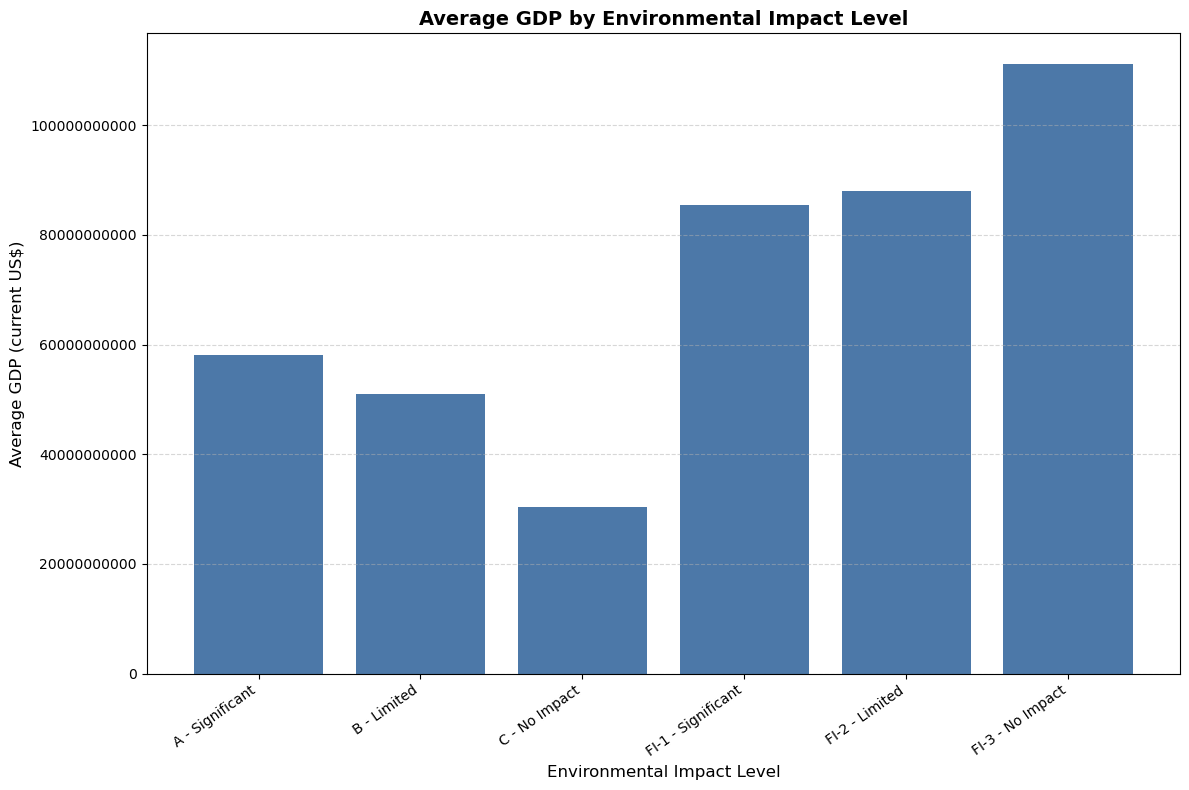

In [118]:
# Plot 1: Customized bar chart or line chart of aggregated subgroups
import matplotlib.pyplot as plt

impact_gdp = merged_df.groupby("environmental_impact_level")["gdp"].mean()

plt.figure(figsize=(12, 8))

plt.bar(
    impact_gdp.index,
    impact_gdp.values,
    color="#4C78A8"
)

plt.title("Average GDP by Environmental Impact Level", fontsize=14, fontweight="bold")
plt.xlabel("Environmental Impact Level", fontsize=12)
plt.ylabel("Average GDP (current US$)", fontsize=12)

plt.xticks(rotation=35, ha="right")
plt.ticklabel_format(style="plain", axis="y")
plt.grid(axis="y", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

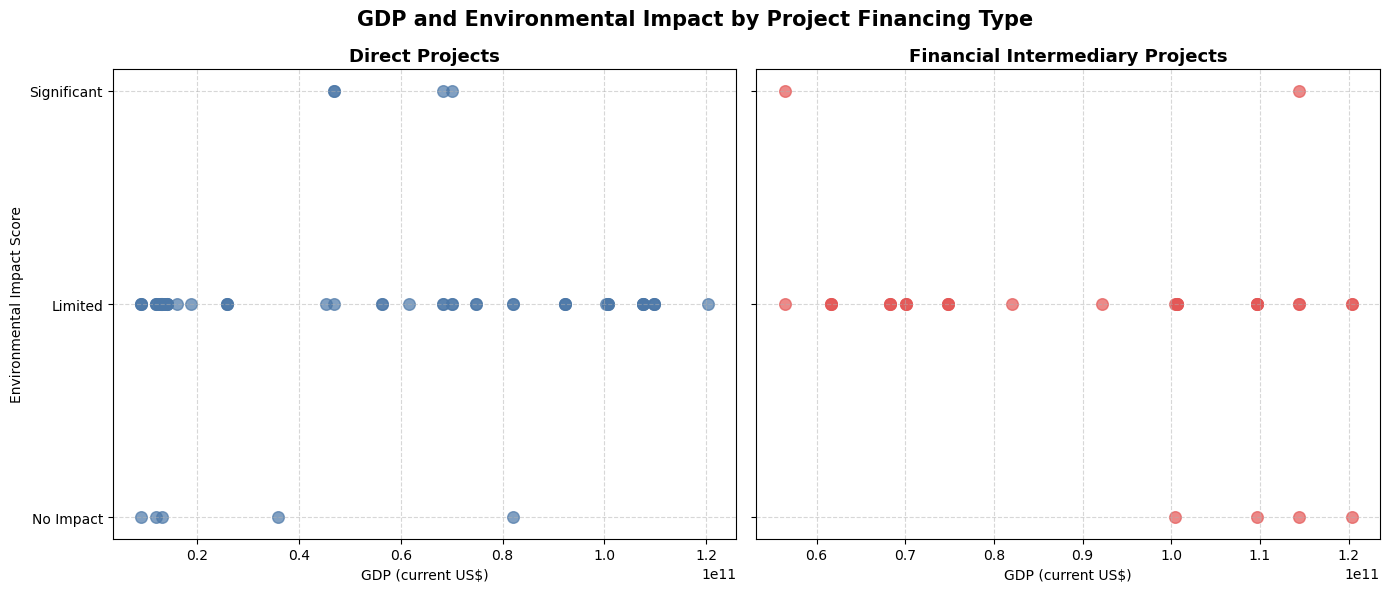

In [119]:
# Plot 2: Customized scatter plot of primary policy variables
impact_score_map = {
    "C - No Impact": 1,
    "B - Limited": 2,
    "A - Significant": 3,
    "FI-3 - No Impact": 1,
    "FI-2 - Limited": 2,
    "FI-1 - Significant": 3
}

merged_df["impact_score"] = merged_df["environmental_impact_level"].map(impact_score_map)

# Split into direct projects and financial intermediary projects
direct_df = merged_df[
    merged_df["environmental_impact_level"].isin(
        ["A - Significant", "B - Limited", "C - No Impact"]
    )
]

fi_df = merged_df[
    merged_df["environmental_impact_level"].isin(
        ["FI-1 - Significant", "FI-2 - Limited", "FI-3 - No Impact"]
    )
]

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

axes[0].scatter(
    direct_df["gdp"],
    direct_df["impact_score"],
    color="#4C78A8",
    alpha=0.7,
    s=70
)

axes[0].set_title("Direct Projects", fontsize=13, fontweight="bold")
axes[0].set_xlabel("GDP (current US$)")
axes[0].set_ylabel("Environmental Impact Score")
axes[0].set_yticks([1, 2, 3])
axes[0].set_yticklabels(["No Impact", "Limited", "Significant"])
axes[0].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
axes[0].grid(True, linestyle="--", alpha=0.5)

axes[1].scatter(
    fi_df["gdp"],
    fi_df["impact_score"],
    color="#E45756",
    alpha=0.7,
    s=70
)

axes[1].set_title("Financial Intermediary Projects", fontsize=13, fontweight="bold")
axes[1].set_xlabel("GDP (current US$)")
axes[1].set_yticks([1, 2, 3])
axes[1].set_yticklabels(["No Impact", "Limited", "Significant"])
axes[1].ticklabel_format(style="sci", axis="x", scilimits=(0, 0))
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle(
    "GDP and Environmental Impact by Project Financing Type",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

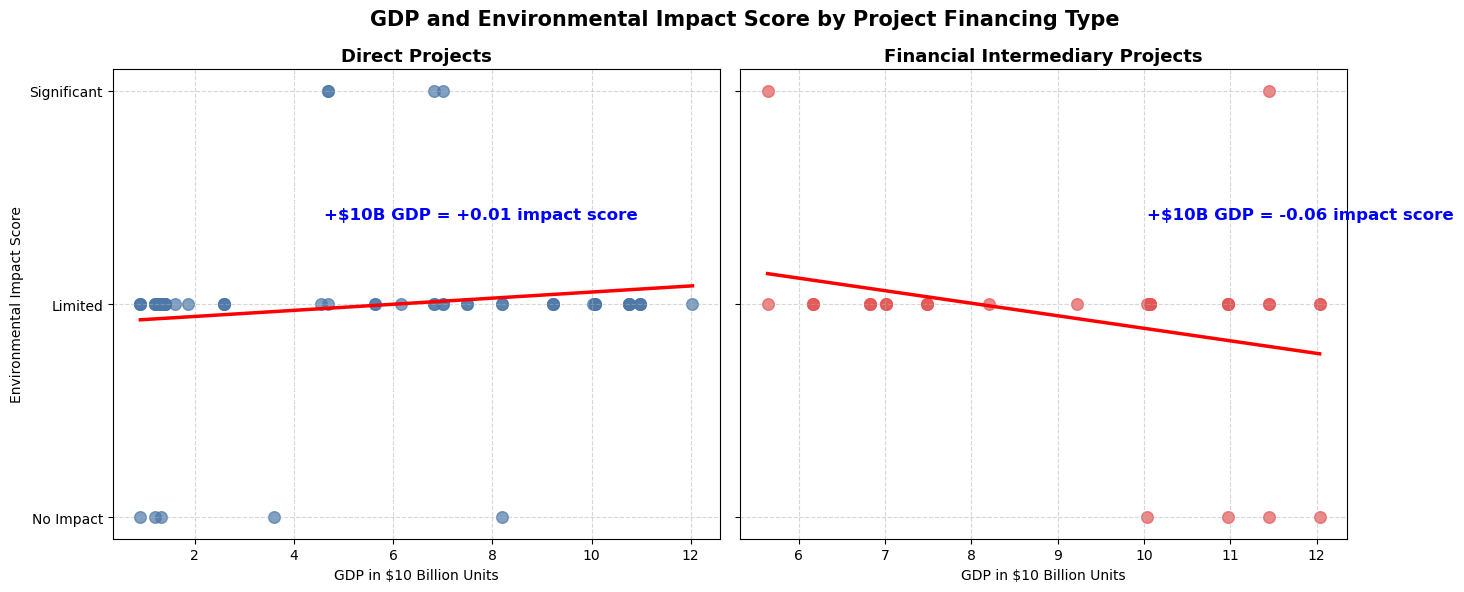

Direct Projects Regression Results
coef: 0.014298460841751688
p-value: 0.25723319534059674
R-squared: 0.020654066838651675
n: 64

Financial Intermediary Projects Regression Results
coef: -0.05876879900767902
p-value: 0.0801251661005315
R-squared: 0.09261921359013081
n: 34


In [120]:
# Fit a simple linear regression and overlay the line of best fit
import statsmodels.api as sm
import numpy as np

# Split direct projects and financial intermediary projects
direct_df = merged_df[
    merged_df["environmental_impact_level"].isin(
        ["A - Significant", "B - Limited", "C - No Impact"]
    )
].dropna(subset=["gdp", "impact_score"]).copy()

fi_df = merged_df[
    merged_df["environmental_impact_level"].isin(
        ["FI-1 - Significant", "FI-2 - Limited", "FI-3 - No Impact"]
    )
].dropna(subset=["gdp", "impact_score"]).copy()

# Scale GDP to make the coefficient easier to interpret
direct_df["gdp_10b"] = direct_df["gdp"] / 10_000_000_000
fi_df["gdp_10b"] = fi_df["gdp"] / 10_000_000_000

# Direct projects OLS regression
X_direct = sm.add_constant(direct_df["gdp_10b"])
y_direct = direct_df["impact_score"]
direct_model = sm.OLS(y_direct, X_direct).fit()

# Financial intermediary projects OLS regression
X_fi = sm.add_constant(fi_df["gdp_10b"])
y_fi = fi_df["impact_score"]
fi_model = sm.OLS(y_fi, X_fi).fit()

# Get slopes
direct_slope = direct_model.params["gdp_10b"]
fi_slope = fi_model.params["gdp_10b"]

# Create prediction lines
x_direct_line = np.linspace(direct_df["gdp_10b"].min(), direct_df["gdp_10b"].max(), 100)
X_direct_line = sm.add_constant(x_direct_line)
y_direct_line = direct_model.predict(X_direct_line)

x_fi_line = np.linspace(fi_df["gdp_10b"].min(), fi_df["gdp_10b"].max(), 100)
X_fi_line = sm.add_constant(x_fi_line)
y_fi_line = fi_model.predict(X_fi_line)

# Plot regression results
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)

# Direct projects plot
axes[0].scatter(
    direct_df["gdp_10b"],
    direct_df["impact_score"],
    color="#4C78A8",
    alpha=0.7,
    s=70
)

axes[0].plot(
    x_direct_line,
    y_direct_line,
    color="red",
    linewidth=2.5
)

axes[0].annotate(
    f"+$10B GDP = {direct_slope:+.2f} impact score",
    xy=(direct_df["gdp_10b"].median(), 2.4),
    color="blue",
    fontsize=12,
    fontweight="bold"
)

axes[0].set_title("Direct Projects", fontsize=13, fontweight="bold")
axes[0].set_xlabel("GDP in $10 Billion Units")
axes[0].set_ylabel("Environmental Impact Score")
axes[0].set_yticks([1, 2, 3])
axes[0].set_yticklabels(["No Impact", "Limited", "Significant"])
axes[0].grid(True, linestyle="--", alpha=0.5)

# Financial intermediary projects plot
axes[1].scatter(
    fi_df["gdp_10b"],
    fi_df["impact_score"],
    color="#E45756",
    alpha=0.7,
    s=70
)

axes[1].plot(
    x_fi_line,
    y_fi_line,
    color="red",
    linewidth=2.5
)

axes[1].annotate(
    f"+$10B GDP = {fi_slope:+.2f} impact score",
    xy=(fi_df["gdp_10b"].median(), 2.4),
    color="blue",
    fontsize=12,
    fontweight="bold"
)

axes[1].set_title("Financial Intermediary Projects", fontsize=13, fontweight="bold")
axes[1].set_xlabel("GDP in $10 Billion Units")
axes[1].set_yticks([1, 2, 3])
axes[1].set_yticklabels(["No Impact", "Limited", "Significant"])
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.suptitle(
    "GDP and Environmental Impact Score by Project Financing Type",
    fontsize=15,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# Print regression summaries
print("Direct Projects Regression Results")
print("coef:", direct_model.params["gdp_10b"])
print("p-value:", direct_model.pvalues["gdp_10b"])
print("R-squared:", direct_model.rsquared)
print("n:", int(direct_model.nobs))

print("\nFinancial Intermediary Projects Regression Results")
print("coef:", fi_model.params["gdp_10b"])
print("p-value:", fi_model.pvalues["gdp_10b"])
print("R-squared:", fi_model.rsquared)
print("n:", int(fi_model.nobs))

- *Extra Credit: From a policy perspective, the results suggest that Kenya’s economic conditions may shape the type of World Bank/IFC financing and the environmental risk profile of projects in different ways. For direct projects, the coefficient is positive: a $10 billion increase in GDP is associated with a 0.014 increase in environmental impact score. Although this relationship is weak and not statistically significant, it suggests that when Kenya’s economy is stronger, direct financing may be more likely to support larger infrastructure, industrial, or productive-sector projects that carry greater environmental impacts. This could reflect greater government and investor capacity to implement large-scale development projects during higher-GDP periods. In contrast, financial intermediary projects show the opposite pattern. The coefficient is -0.059, meaning that a $10 billion increase in GDP is associated with a 0.059 decrease in environmental impact score. This suggests that when GDP is higher, financial intermediary financing may be directed more toward lower-impact or lower-risk activities. One possible explanation is that in stronger economic periods, banks and other financial intermediaries can support a broader range of smaller firms or service-sector activities, which may have lower direct environmental impacts. The policy implication is that environmental safeguards should be designed differently for direct projects and financial intermediary projects. Direct projects may require stronger environmental review during periods of economic expansion, when higher-impact investments become more feasible. For financial intermediary projects, policymakers may need to focus on how banks and funds screen and monitor downstream investments, especially when economic conditions are weaker and FI financing may be more associated with higher-impact activities. However, these findings should be interpreted cautiously. The direct project result is not statistically significant at the 5% level, and the FI result is only suggestive with a p-value of 0.080. The low R-squared values also show that GDP explains only a small share of variation in environmental impact scores. Therefore, the results should be treated as preliminary policy evidence rather than proof of causality.

### **Submission Checklist**

- **Out-of-the-Box Execution**
  - Select `Kernel -> Restart & Run All` to verify all cells run without error.
- **Reproducibility & Paths**
  - Verify that both the notebook and the dataset are saved and committed in Git.
  - Ensure all files are loaded using relative paths.
- **Visual Elements & Design**
  - Ensure all plots are fully customized, clearly labeled, and have titles.